In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import xarray as xr
import harmonica as hm
from pyproj import Transformer

In [75]:
csv_path = "../../data/gravity/Onyx_Profile_DEM_Elevations_AND_Positions.csv"
tif_path = "../../data/LiDAR/Onyx_Profile_Merged_DEM_UTM13N.tif"

df = pd.read_csv(csv_path)
df = df.sort_values("station")
df = df.groupby("station", as_index=False).mean(numeric_only=True)

df.head()

,station,lat,lon,elev_m,grav_mean,grav_dc,grav_rel,FAC,FAA,instrument,...,gps_minus_dem_fixed_m,elevation_m_original,elevation_m_fixed_dem,height_above_reference_m,bouguer_correction_mgal,gravity_simple_bouguer_corrected_mgal,elev_m_original,lon_original_gps,lat_original_gps,elev_m_original_gps
0,1.0,40.478700,-106.835500,2111.5461,3891.8183,3891.8184,0.0162,0.495071,651.9238,41422.0,...,0.921857,2112.468,2111.5461,1.604248,0.179601,0.331670,2111.5461,-106.8355,40.4787,2111.5461
1,3.0,40.478714,-106.835507,2111.4756,3891.8427,3891.8428,0.0406,0.473297,651.6708,41422.0,...,0.093414,2111.569,2111.4756,1.533691,0.171702,0.342196,2111.4756,-106.8355,40.4787,2111.4756
2,4.0,40.478721,-106.835511,2111.4346,3891.8650,3891.8652,0.0630,0.460640,651.7311,41422.0,...,0.257430,2111.692,2111.4346,1.492676,0.167110,0.356530,2111.4346,-106.8355,40.4787,2111.4346
3,5.0,40.478729,-106.835514,2111.3806,3891.8853,3891.8855,0.0833,0.443989,651.8040,41422.0,...,0.481385,2111.862,2111.3806,1.438721,0.161069,0.366220,2111.3806,-106.8355,40.4787,2111.3806
4,6.0,40.478736,-106.835518,2111.3364,3891.8993,3891.8996,0.0974,0.430352,651.7958,41422.0,...,0.453574,2111.790,2111.3364,1.394531,0.156122,0.371630,2111.3364,-106.8355,40.4787,2111.3364


In [76]:
# Convert station GPS lat/lon to UTM 13N
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32613", always_xy=True)

df["utm_easting"], df["utm_northing"] = transformer.transform(
    df["lon_original_gps"].values,
    df["lat_original_gps"].values
)

df[["station", "utm_easting", "utm_northing", "elev_m_original_gps"]].head()

,station,utm_easting,utm_northing,elev_m_original_gps
0,1.0,344417.588274,4.482509e+06,2111.5461
1,3.0,344417.588274,4.482509e+06,2111.4756
2,4.0,344417.588274,4.482509e+06,2111.4346
3,5.0,344417.588274,4.482509e+06,2111.3806
4,6.0,344417.588274,4.482509e+06,2111.3364


In [77]:
# Read merged DEM directly
src = rasterio.open(tif_path)

dem = src.read(1).astype(float)
dem[dem == src.nodata] = np.nan

bounds = src.bounds
res_x, res_y = src.res

print(src.crs)
print(bounds)
print(res_x, res_y)

EPSG:26913
BoundingBox(left=343909.0543421023, bottom=4482008.155752747, right=344918.49253896944, top=4483031.309142507)
0.9143461928144142 0.9143461928144142


In [78]:
# Build DEM coordinate arrays
easting = np.arange(bounds.left + res_x/2, bounds.right, res_x)
northing = np.arange(bounds.top - abs(res_y)/2, bounds.bottom, -abs(res_y))

# Make sure DEM shape matches coordinates
print(dem.shape, len(northing), len(easting))

topography = xr.DataArray(
    dem,
    coords={"northing": northing, "easting": easting},
    dims=("northing", "easting"),
    name="topography"
)

topography

(1119, 1104) 1119 1104


<xarray.DataArray 'topography' (northing: 1119, easting: 1104)> Size: 10MB
array([[          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan, 2121.0637207 , 2120.94604492, ..., 2052.09057617,
        2052.11645508,           nan],
       [          nan, 2121.17114258, 2121.13574219, ..., 2052.10400391,
        2052.11352539,           nan],
       ...,
       [          nan, 2212.02539062, 2211.98095703, ..., 2050.98657227,
        2050.97631836,           nan],
       [          nan, 2212.03271484, 2211.99853516, ..., 2050.97509766,
        2050.98828125,           nan],
       [          nan, 2212.06665039, 2212.04345703, ..., 2050.95776367,
        2051.00805664,           nan]], shape=(1119, 1104))
Coordinates:
  * northing  (northing) float64 9kB 4.483e+06 4.483e+06 ... 4.482e+06 4.482e+06
  * easting   (easting) float64 9kB 3.439e+05 3.439e+05 ... 3.449e+05 3.449e+05

In [102]:
from pyproj import Transformer

# Match the TIFF CRS exactly: EPSG:26913
transformer = Transformer.from_crs("EPSG:4326", "EPSG:26913", always_xy=True)

df["utm_easting"], df["utm_northing"] = transformer.transform(
    df["lon_original_gps"].values,
    df["lat_original_gps"].values
)

print(df[["station", "utm_easting", "utm_northing"]].head())

   station    utm_easting  utm_northing
0      1.0  344417.708774   4482508.451
1      3.0  344417.708774   4482508.451
2      4.0  344417.708774   4482508.451
3      5.0  344417.708774   4482508.451
4      6.0  344417.708774   4482508.451


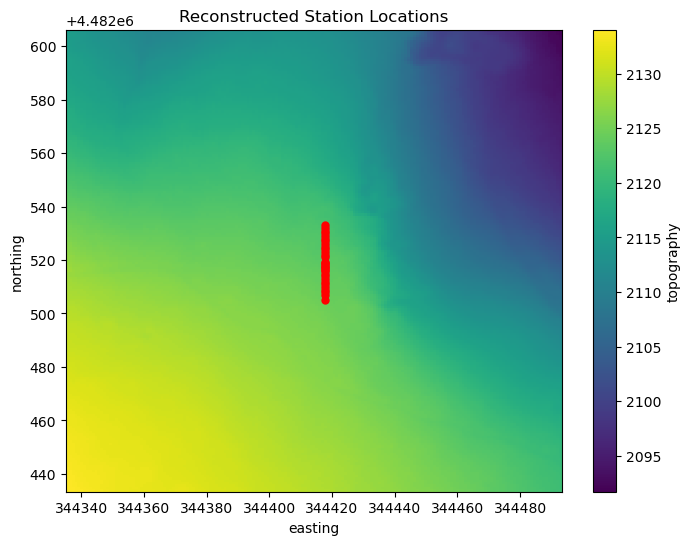

In [103]:
# Use average GPS location as center anchor
x_center = df["utm_easting"].mean()
y_center = df["utm_northing"].mean()

# Station distance along line
s = df["station"] - df["station"].mean()

# Line direction: mostly north-south based on your map
azimuth_deg = 0   # try 0 or 180 depending direction

az = np.deg2rad(azimuth_deg)

df["line_easting"] = x_center + s * np.sin(az)
df["line_northing"] = y_center + s * np.cos(az)

plt.figure(figsize=(8,6))
topo_crop.plot()
plt.scatter(df["line_easting"], df["line_northing"], c="red", s=25)
plt.title("Reconstructed Station Locations")
plt.show()

In [105]:
import harmonica as hm
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

rho = 2670  # kg/m3

reference = df["elev_m_original_gps"].min()

density = xr.where(topo_crop >= reference, rho, -rho)

prisms = hm.prism_layer(
    coordinates=(topo_crop.easting, topo_crop.northing),
    surface=topo_crop,
    reference=reference,
    properties={"density": density},
)

In [106]:
coordinates = (
    df["line_easting"].values,
    df["line_northing"].values,
    df["elev_m_original_gps"].values
)

terrain_raw = prisms.prism_layer.gravity(
    coordinates,
    field="g_z"
)

df["terrain_raw_mgal"] = terrain_raw

# Joe said flip the sign for your gravity convention
df["terrain_fixed_mgal"] = -df["terrain_raw_mgal"]

In [107]:
df[["station","terrain_raw_mgal"]].head()

,station,terrain_raw_mgal
0,1.0,-1.103098
1,3.0,-1.101911
2,4.0,-1.102273
3,5.0,-1.105060
4,6.0,-1.105827


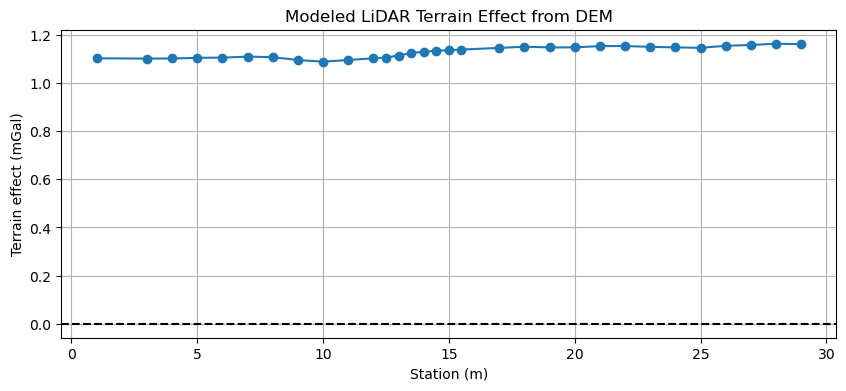

In [108]:
plt.figure(figsize=(10,4))
plt.plot(df["station"], df["terrain_fixed_mgal"], "o-")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Station (m)")
plt.ylabel("Terrain effect (mGal)")
plt.title("Modeled LiDAR Terrain Effect from DEM")
plt.grid(True)
plt.show()

In [109]:
df["g_original"] = df["gravity_tied_mgal"]

z_ref = df["elev_m_original_gps"].min()
df["dz"] = df["elev_m_original_gps"] - z_ref

df["free_air_corr_mgal"] = 0.3086 * df["dz"]
df["g_free_air"] = df["g_original"] + df["free_air_corr_mgal"]

# Simple Bouguer path
bouguer_grad = 0.04193 * (rho / 1000)
df["bouguer_corr_mgal"] = bouguer_grad * df["dz"]
df["g_simple_bouguer"] = df["g_free_air"] - df["bouguer_corr_mgal"]

# Advanced LiDAR path
df["g_lidar_advanced"] = df["g_free_air"] - df["terrain_fixed_mgal"]

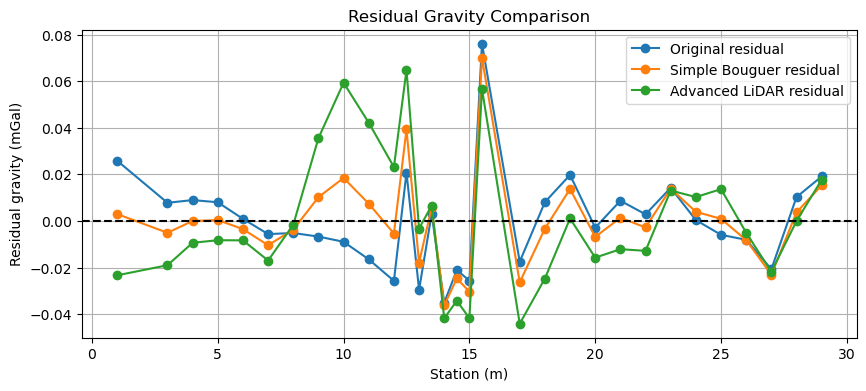

In [110]:
for col in ["g_original", "g_free_air", "g_simple_bouguer", "g_lidar_advanced"]:
    coef = np.polyfit(df["station"], df[col], 1)
    df[col + "_resid"] = df[col] - np.polyval(coef, df["station"])

plt.figure(figsize=(10,4))
plt.plot(df["station"], df["g_original_resid"], "o-", label="Original residual")
plt.plot(df["station"], df["g_simple_bouguer_resid"], "o-", label="Simple Bouguer residual")
plt.plot(df["station"], df["g_lidar_advanced_resid"], "o-", label="Advanced LiDAR residual")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Station (m)")
plt.ylabel("Residual gravity (mGal)")
plt.title("Residual Gravity Comparison")
plt.grid(True)
plt.legend()
plt.show()

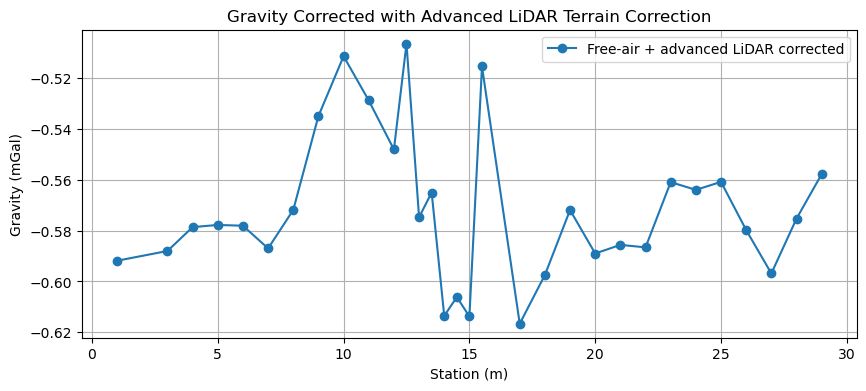

In [111]:
plt.figure(figsize=(10,4))

plt.plot(
    df["station"],
    df["g_lidar_advanced"],
    "o-",
    label="Free-air + advanced LiDAR corrected"
)

plt.xlabel("Station (m)")
plt.ylabel("Gravity (mGal)")
plt.title("Gravity Corrected with Advanced LiDAR Terrain Correction")
plt.grid(True)
plt.legend()
plt.show()

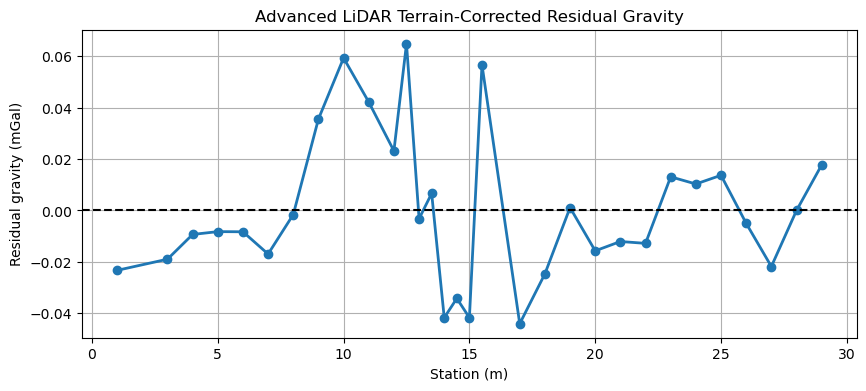

In [112]:
plt.figure(figsize=(10,4))

plt.plot(
    df["station"],
    df["g_lidar_advanced_resid"],
    marker="o",
    linewidth=2
)

plt.axhline(0, color="k", linestyle="--")

plt.xlabel("Station (m)")
plt.ylabel("Residual gravity (mGal)")
plt.title("Advanced LiDAR Terrain-Corrected Residual Gravity")
plt.grid(True)

plt.show()